# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a statistical technique used for dimensionality reduction. It transforms the data into a new coordinate system such that the greatest variance by any projection of the data comes to lie on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on.

## Key Concepts

- **Dimensionality Reduction**: PCA reduces the number of variables in the data while retaining as much variability as possible.
- **Principal Components**: New variables that are linear combinations of the original variables. They are orthogonal (uncorrelated) and ordered by the amount of variance they capture from the data.
- **Explained Variance**: The amount of variance captured by each principal component. It helps in understanding how much information (variance) is retained by each principal component.
- **Cumulative Explained Variance**: The cumulative sum of explained variance ratios of the principal components. It helps in determining the number of principal components needed to capture a desired amount of variance.

## Steps in PCA

1. **Standardize the Data**: Standardize the dataset to have a mean of zero and a standard deviation of one.
2. **Compute the Covariance Matrix**: Calculate the covariance matrix to understand how the variables are related to each other.
3. **Compute the Eigenvalues and Eigenvectors**: Determine the eigenvalues and eigenvectors of the covariance matrix. The eigenvectors determine the direction of the new feature space, and the eigenvalues determine their magnitude.
4. **Sort Eigenvalues and Eigenvectors**: Sort the eigenvalues in descending order and arrange the eigenvectors accordingly.
5. **Select Principal Components**: Choose the top k eigenvectors that correspond to the k largest eigenvalues to form a new feature space.
6. **Transform the Data**: Project the original data onto the new feature space to obtain the principal components.

## Applications of PCA

- **Data Visualization**: Reducing high-dimensional data to 2 or 3 dimensions for visualization.
- **Noise Reduction**: Removing noise from the data by keeping only the principal components with the highest variance.
- **Feature Extraction**: Identifying the most important features in the data.
- **Preprocessing for Machine Learning**: Reducing the dimensionality of the data to improve the performance of machine learning algorithms.

In [2]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## 1. Load the iris dataset

In [9]:
# Exercise 2: Load the Dataset
# Load the Iris dataset from sklearn
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
print(f"X shape: {X.shape}")

X shape: (150, 4)


### 2. Standardize the features

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"X[0]: {X[0]}")
print(f"X_scaled[0]: {X_scaled[0]}")

X[0]: [5.1 3.5 1.4 0.2]
X_scaled[0]: [-0.90068117  1.01900435 -1.34022653 -1.3154443 ]


### 3. Apply PCA to the 2 pricinpal components

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"X_pca.shape: {X_pca.shape}")

X_pca.shape: (150, 2)


### 4. Visualize the PCA results with a scatter plot

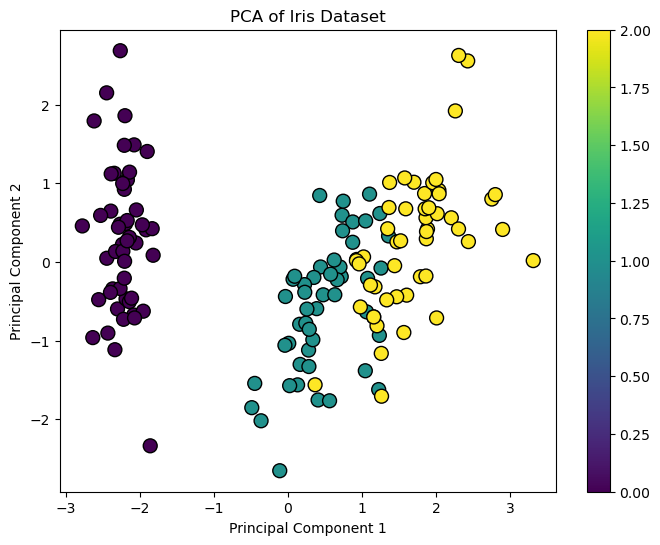

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Iris Dataset')
plt.colorbar()
plt.show()

### 5. Print the explained variance ratio of each principal component 


The explained variance ratio in PCA indicates the proportion of the dataset's total variance that is captured by each principal component. It helps in understanding the importance of each principal component in terms of the amount of information (variance) it retains from the original dataset.

- **Explained Variance**: The amount of variance captured by each principal component.
- **Explained Variance Ratio**: The ratio of the explained variance of a principal component to the total variance of the dataset. It is calculated as:


$$\text{Explained Variance Ratio} = \frac{\text{Explained Variance of Principal Component}}{\text{Total Variance}}$$

- **Cumulative Explained Variance**: The cumulative sum of the explained variance ratios of the principal components. It helps in determining the number of principal components needed to capture a desired amount of variance.

For example, if the explained variance ratio of the first principal component is 0.73, it means that 73% of the total variance in the dataset is captured by the first principal component. If the second principal component has an explained variance ratio of 0.23, it means that an additional 23% of the total variance is captured by the second principal component. Together, the first two principal components capture 96% of the total variance in the dataset.

Understanding the explained variance ratio is crucial for deciding how many principal components to retain in order to achieve a balance between dimensionality reduction and information retention.
```

In [12]:
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance by each component: {explained_variance}')

Explained variance by each component: [0.72962445 0.22850762]


### 6. Plot the cumulative explained variance

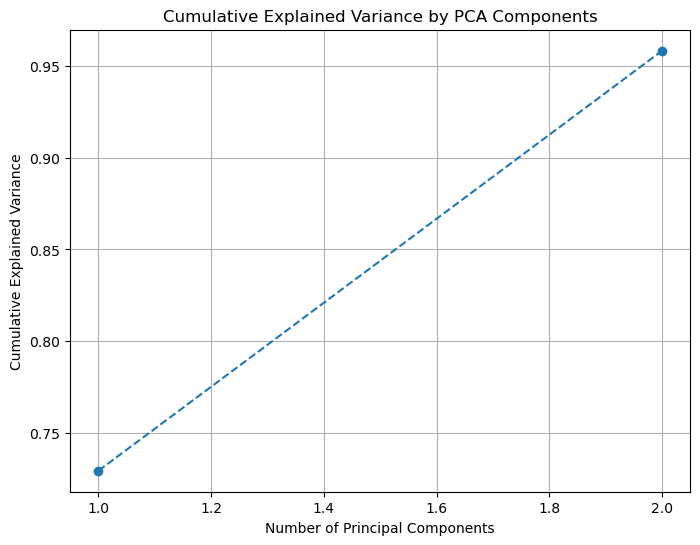

In [13]:
cumulative_explained_variance = np.cumsum(explained_variance)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid()
plt.show()

### 7. Reconstruct the original data using the principal components

In [15]:
X_reconstructed = pca.inverse_transform(X_pca)
print(f'Reconstructed data (first 5 samples):\n{X_reconstructed[:5]}')

Reconstructed data (first 5 samples):
[[-0.99888895  1.05319838 -1.30270654 -1.24709825]
 [-1.33874781 -0.06192302 -1.22432772 -1.22057235]
 [-1.36096129  0.32111685 -1.38060338 -1.35833824]
 [-1.42359795  0.0677615  -1.34922386 -1.33881298]
 [-1.00113823  1.24091818 -1.37125365 -1.30661752]]


### 8. Compare the original and restructured data 

In [34]:
comparison = np.hstack((X_scaled[:5], X_reconstructed[:5]))
print(f'Original vs Reconstructed data (first 5 samples):\n{comparison}')

Original vs Reconstructed data (first 5 samples):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443  -0.99888895  1.05319838
  -1.30270654 -1.24709825]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443  -1.33874781 -0.06192302
  -1.22432772 -1.22057235]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443  -1.36096129  0.32111685
  -1.38060338 -1.35833824]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443  -1.42359795  0.0677615
  -1.34922386 -1.33881298]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443  -1.00113823  1.24091818
  -1.37125365 -1.30661752]]


### 8bis. In the following generated data, do the following steps:
#### 1. Plot the data
#### 2. Standardized and apply PCA with 2 principal components
#### 3. Plot the PCA
#### 4. Apply PCA with 1 principal component and plot it
#### 5. Transform back the data into 2D using inverse transform and plot the reconstructed data
#### 6. Analyze the result, compared to the initial data

C:\Users\u011513\AppData\Local\Temp\ipykernel_20732\756001972.py:4: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X_generated = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0.95], [0.9, 1]], size=100)


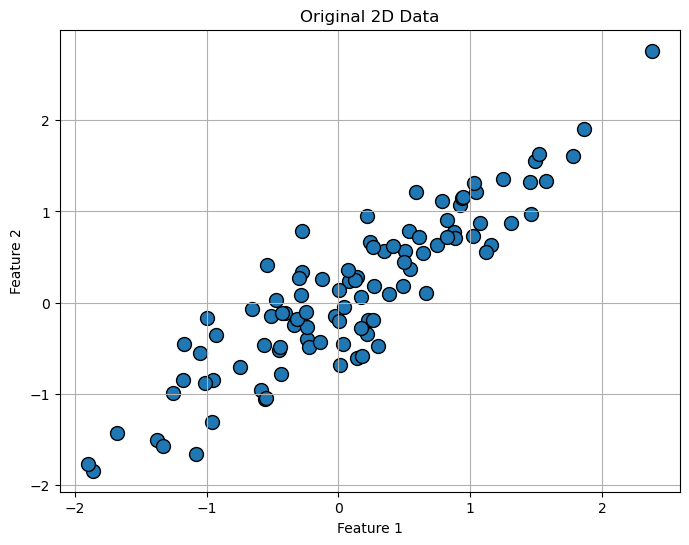

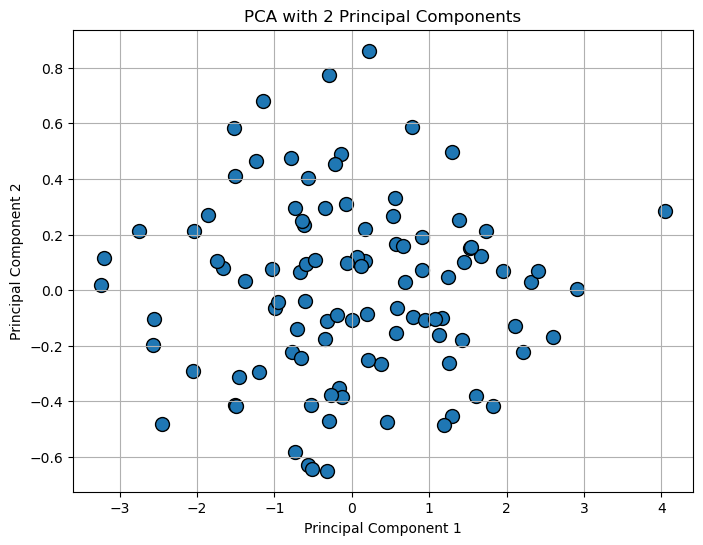

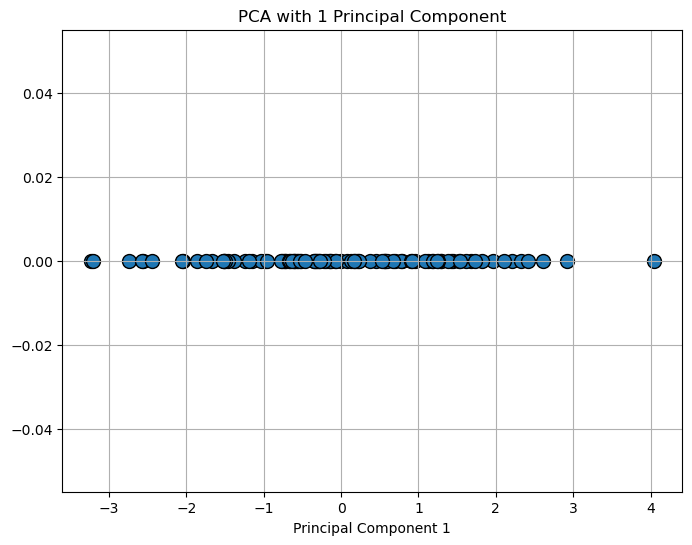

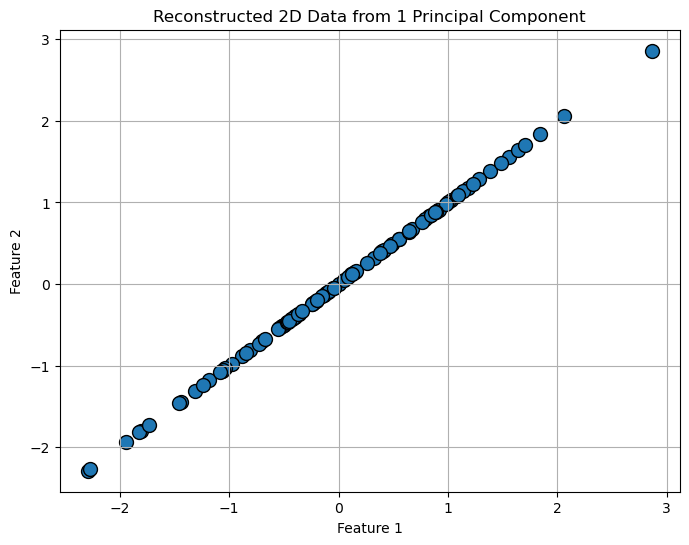

In [33]:
# Generate 2D data
np.random.seed(42)

X_generated = np.random.multivariate_normal(mean=[0, 0], cov=[[1, 0.95], [0.9, 1]], size=100)

# Plot the original data
plt.figure(figsize=(8, 6))
plt.scatter(X_generated[:, 0], X_generated[:, 1], edgecolor='k', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Original 2D Data')
plt.grid()
plt.show()

# Standardize the data
scaler_generated = StandardScaler()
X_generated_scaled = scaler_generated.fit_transform(X_generated)

# Apply PCA with 2 principal components
pca_2d = PCA(n_components=2)
X_generated_pca_2d = pca_2d.fit_transform(X_generated_scaled)

# Plot the transformed data with 2 principal components
plt.figure(figsize=(8, 6))
plt.scatter(X_generated_pca_2d[:, 0], X_generated_pca_2d[:, 1], edgecolor='k', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA with 2 Principal Components')
plt.grid()
plt.show()

# Apply PCA with 1 principal component
pca_1d = PCA(n_components=1)
X_generated_pca_1d = pca_1d.fit_transform(X_generated_scaled)

# Plot the transformed data with 1 principal component
plt.figure(figsize=(8, 6))
plt.scatter(X_generated_pca_1d[:, 0], np.zeros_like(X_generated_pca_1d[:, 0]), edgecolor='k', s=100)
plt.xlabel('Principal Component 1')
plt.title('PCA with 1 Principal Component')
plt.grid()
plt.show()

# Transform the data back to 2D using inverse transform
X_generated_reconstructed = pca_1d.inverse_transform(X_generated_pca_1d)

# Plot the reconstructed data
plt.figure(figsize=(8, 6))
plt.scatter(X_generated_reconstructed[:, 0], X_generated_reconstructed[:, 1], edgecolor='k', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Reconstructed 2D Data from 1 Principal Component')
plt.grid()
plt.show()


### 9. Redo a PCA on a different dataset this time (e.g, Diabetes)

* Try out different number of principal components and find a good compromise of reduction without discarding too much information.

Number of features: 10


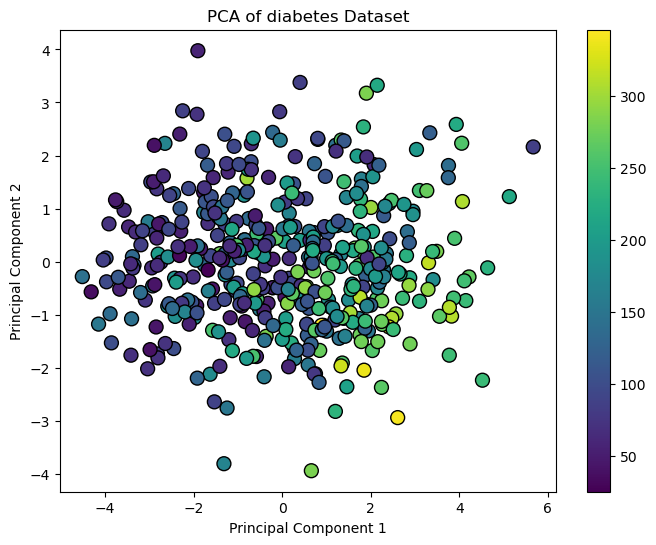

Explained variance by each component: [0.40242108 0.14923197]


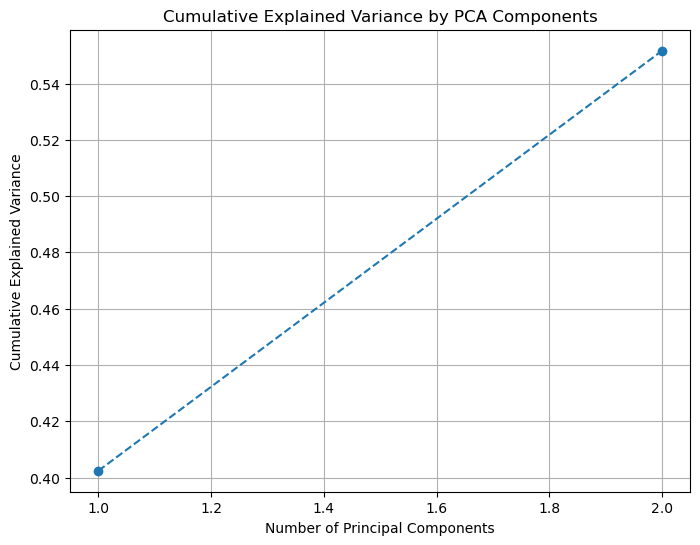

In [51]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X_diabetes = diabetes.data
y_diabetes = diabetes.target
print(f"Number of features: {X_diabetes.shape[1]}")
X_diabetes_scaled = scaler.fit_transform(X_diabetes)

pca_diabetes = PCA(n_components=2)
X_diabetes_pca = pca_diabetes.fit_transform(X_diabetes_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_diabetes_pca[:, 0], X_diabetes_pca[:, 1], c=y_diabetes, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of diabetes Dataset')
plt.colorbar()
plt.show()

# Calculate the explained variance by each component
explained_variance_diabetes = pca_diabetes.explained_variance_ratio_
print(f'Explained variance by each component: {explained_variance_diabetes}')

# Calculate the cumulative explained variance
cumulative_explained_variance_diabetes = np.cumsum(explained_variance_diabetes)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_explained_variance_diabetes) + 1), cumulative_explained_variance_diabetes, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid()
plt.show()


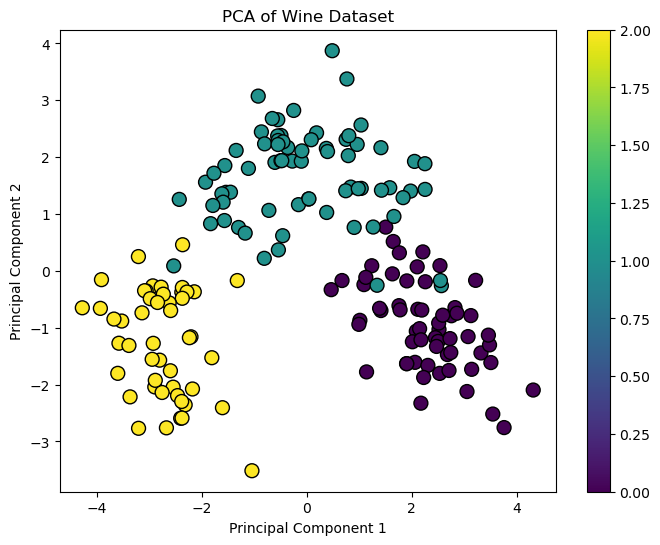

Explained variance by each component: [0.36198848 0.1920749 ]


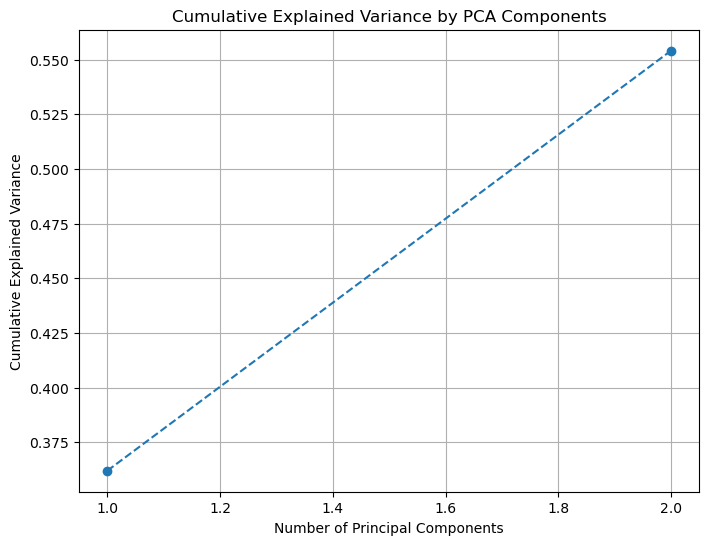

In [52]:

from sklearn.datasets import load_wine
data = load_wine()
X_wine = data.data
y_wine = data.target
# Standardize the Wine dataset
X_wine_scaled = scaler.fit_transform(X_wine)

# Apply PCA to reduce the Wine dataset to 2 principal components
pca_wine = PCA(n_components=2)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

# Visualize the PCA result for the Wine dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_wine_pca[:, 0], X_wine_pca[:, 1], c=y_wine, cmap='viridis', edgecolor='k', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Wine Dataset')
plt.colorbar()
plt.show()

# Calculate the explained variance by each component
explained_variance_wine = pca_wine.explained_variance_ratio_
print(f'Explained variance by each component: {explained_variance_wine}')

# Calculate the cumulative explained variance
cumulative_explained_variance_wine = np.cumsum(explained_variance_wine)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_explained_variance_wine) + 1), cumulative_explained_variance_wine, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid()
plt.show()

* To go further, you can fix the dataset, fix the model type and train several models on different transformed datasets after PCA. This can be a good study to find a compromise between necessary information, performance and model efficiency.